In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import pandas as pd

raw_path = "/content/drive/MyDrive/student-risk-ml-project/data/raw/student-por.csv"

df = pd.read_csv(raw_path, sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [15]:
import os

processed_dir = "/content/drive/MyDrive/student-risk-ml-project/data/processed"

os.makedirs(processed_dir, exist_ok=True)

In [17]:
cleaned_df = df.copy()

In [18]:
output_path = processed_dir + "/student_cleaned.csv"

cleaned_df.to_csv(output_path, index=False)

print("Saved successfully:", output_path)

Saved successfully: /content/drive/MyDrive/student-risk-ml-project/data/processed/student_cleaned.csv


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [20]:
raw_path = "/content/drive/MyDrive/student-risk-ml-project/data/raw/student-por.csv"

df = pd.read_csv(raw_path, sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [21]:
print("Dataset shape:", df.shape)

Dataset shape: (649, 33)


In [22]:
cleaned_df = df.copy()

In [23]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [24]:
print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])

Rows: 649
Columns: 33


In [25]:
missing_values = cleaned_df.isnull().sum()

print(missing_values)
print("\nTotal missing values:", missing_values.sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total missing values: 0


 **Missing Value Finding**

No missing values were identified in the dataset. Therefore, no imputation or row removal was required.

In [26]:
duplicate_count = cleaned_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


**Duplicate Check**

No exact duplicate rows were identified. Therefore, no records were removed as duplicates.

In [27]:
numerical_cols = cleaned_df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = cleaned_df.select_dtypes(include=["object"]).columns

print("Numerical columns:", len(numerical_cols))
print(list(numerical_cols))

print("\nCategorical columns:", len(categorical_cols))
print(list(categorical_cols))

Numerical columns: 16
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Categorical columns: 17
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [28]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(cleaned_df[col].value_counts())


school:
school
GP    423
MS    226
Name: count, dtype: int64

sex:
sex
F    383
M    266
Name: count, dtype: int64

address:
address
U    452
R    197
Name: count, dtype: int64

famsize:
famsize
GT3    457
LE3    192
Name: count, dtype: int64

Pstatus:
Pstatus
T    569
A     80
Name: count, dtype: int64

Mjob:
Mjob
other       258
services    136
at_home     135
teacher      72
health       48
Name: count, dtype: int64

Fjob:
Fjob
other       367
services    181
at_home      42
teacher      36
health       23
Name: count, dtype: int64

reason:
reason
course        285
home          149
reputation    143
other          72
Name: count, dtype: int64

guardian:
guardian
mother    455
father    153
other      41
Name: count, dtype: int64

schoolsup:
schoolsup
no     581
yes     68
Name: count, dtype: int64

famsup:
famsup
yes    398
no     251
Name: count, dtype: int64

paid:
paid
no     610
yes     39
Name: count, dtype: int64

activities:
activities
no     334
yes    315
Name: count, dty

In [29]:
range_check = pd.DataFrame({
    "Minimum": cleaned_df[numerical_cols].min(),
    "Maximum": cleaned_df[numerical_cols].max(),
    "Unique Values": cleaned_df[numerical_cols].nunique()
})

range_check

,Minimum,Maximum,Unique Values
age,15,22,8
Medu,0,4,5
Fedu,0,4,5
traveltime,1,4,4
studytime,1,4,4
failures,0,3,4
famrel,1,5,5
freetime,1,5,5
goout,1,5,5
Dalc,1,5,5


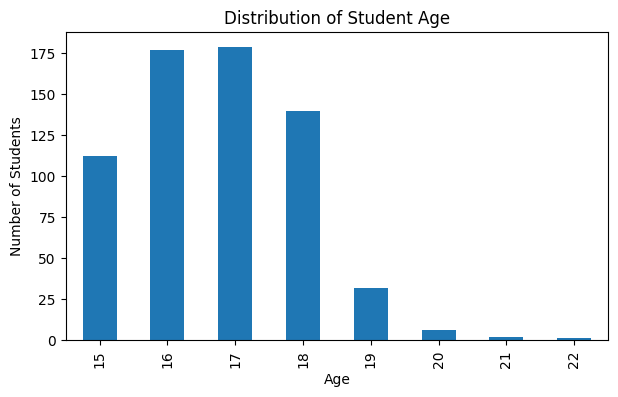

In [30]:
plt.figure(figsize=(7, 4))
cleaned_df["age"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Student Age")
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.show()

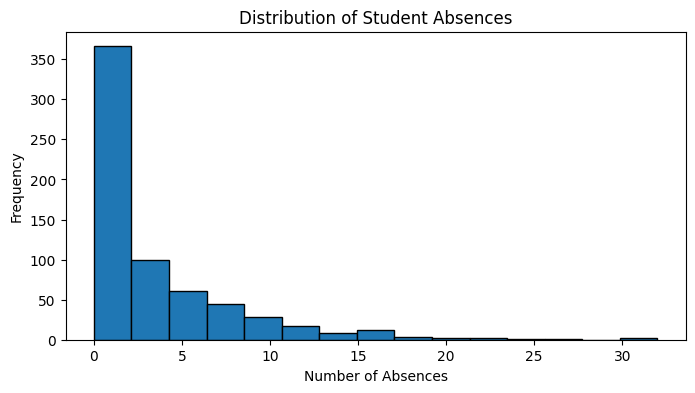

In [31]:
plt.figure(figsize=(8, 4))

plt.hist(cleaned_df["absences"], bins=15, edgecolor="black")

plt.title("Distribution of Student Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Frequency")
plt.show()

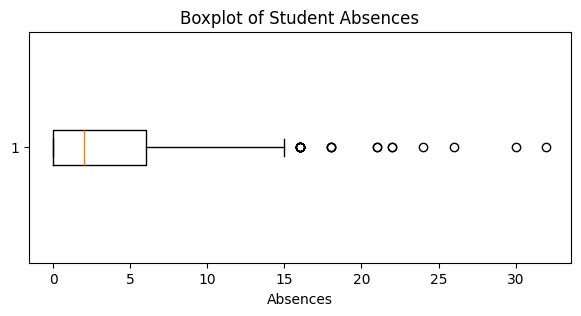

In [32]:
plt.figure(figsize=(7, 3))

plt.boxplot(cleaned_df["absences"], vert=False)

plt.title("Boxplot of Student Absences")
plt.xlabel("Absences")

plt.show()

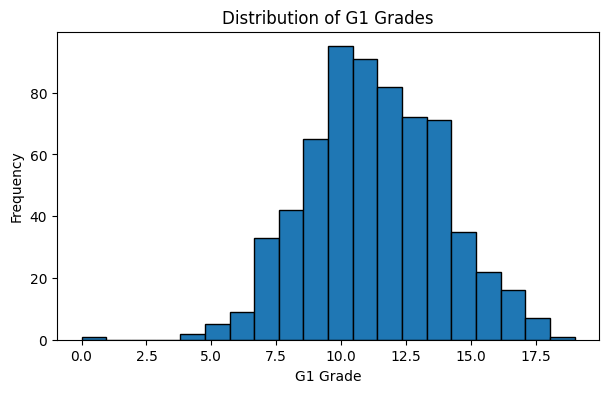

In [33]:
plt.figure(figsize=(7, 4))

plt.hist(cleaned_df["G1"], bins=20, edgecolor="black")

plt.title("Distribution of G1 Grades")
plt.xlabel("G1 Grade")
plt.ylabel("Frequency")

plt.show()

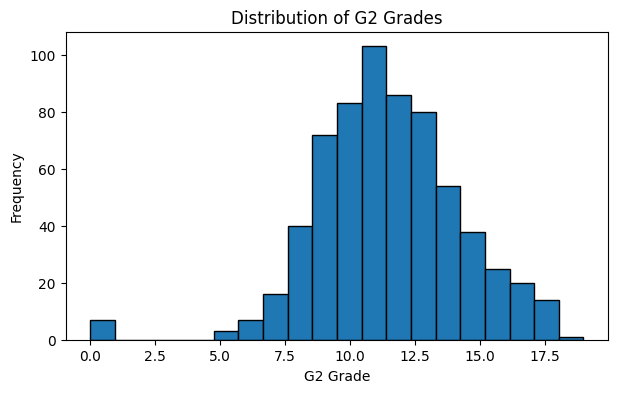

In [34]:
plt.figure(figsize=(7, 4))

plt.hist(cleaned_df["G2"], bins=20, edgecolor="black")

plt.title("Distribution of G2 Grades")
plt.xlabel("G2 Grade")
plt.ylabel("Frequency")

plt.show()

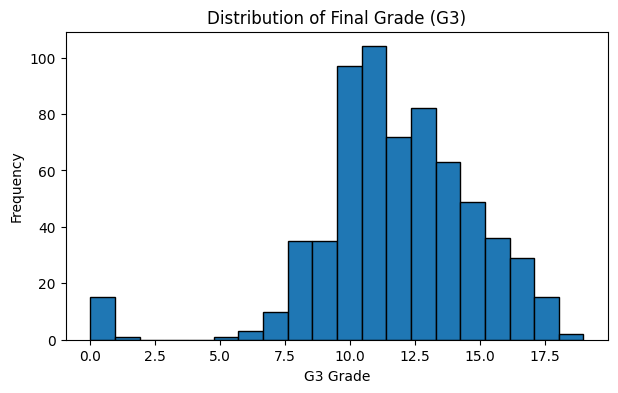

In [35]:
plt.figure(figsize=(7, 4))

plt.hist(cleaned_df["G3"], bins=20, edgecolor="black")

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("G3 Grade")
plt.ylabel("Frequency")

plt.show()

In [36]:
quality_checks = {
    "Invalid age": ((cleaned_df["age"] < 15) | (cleaned_df["age"] > 22)).sum(),
    "Invalid G1": ((cleaned_df["G1"] < 0) | (cleaned_df["G1"] > 20)).sum(),
    "Invalid G2": ((cleaned_df["G2"] < 0) | (cleaned_df["G2"] > 20)).sum(),
    "Invalid G3": ((cleaned_df["G3"] < 0) | (cleaned_df["G3"] > 20)).sum(),
    "Negative absences": (cleaned_df["absences"] < 0).sum()
}

pd.Series(quality_checks)

,0
Invalid age,0
Invalid G1,0
Invalid G2,0
Invalid G3,0
Negative absences,0


In [37]:
for col in categorical_cols:
    print(col, ":", sorted(cleaned_df[col].unique()))

school : ['GP', 'MS']
sex : ['F', 'M']
address : ['R', 'U']
famsize : ['GT3', 'LE3']
Pstatus : ['A', 'T']
Mjob : ['at_home', 'health', 'other', 'services', 'teacher']
Fjob : ['at_home', 'health', 'other', 'services', 'teacher']
reason : ['course', 'home', 'other', 'reputation']
guardian : ['father', 'mother', 'other']
schoolsup : ['no', 'yes']
famsup : ['no', 'yes']
paid : ['no', 'yes']
activities : ['no', 'yes']
nursery : ['no', 'yes']
higher : ['no', 'yes']
internet : ['no', 'yes']
romantic : ['no', 'yes']


In [38]:
risk_preview = np.where(cleaned_df["G3"] < 10, "At Risk", "Not At Risk")

pd.Series(risk_preview).value_counts()

,count
Not At Risk,549
At Risk,100


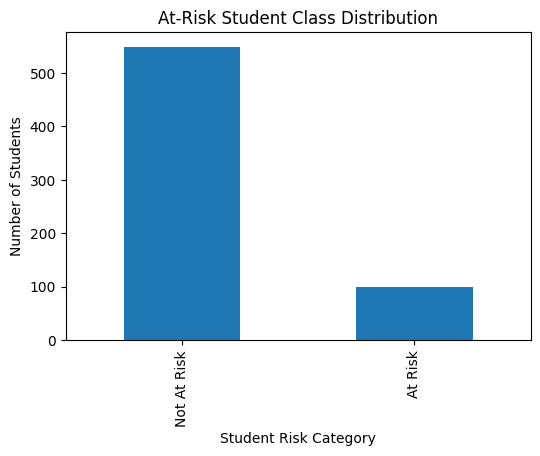

In [39]:
risk_counts = pd.Series(risk_preview).value_counts()

plt.figure(figsize=(6, 4))

risk_counts.plot(kind="bar")

plt.title("At-Risk Student Class Distribution")
plt.xlabel("Student Risk Category")
plt.ylabel("Number of Students")

plt.show()

### **Potential Data Leakage**

The final target will be derived from G3. Therefore, G3 must not be included as an input feature when training the classifier.

G1 and G2 will also be evaluated in the feature-engineering stage because they may provide information that would not be available if the goal is very early student-risk prediction.

In [40]:
import os

processed_dir = "/content/drive/MyDrive/student-risk-ml-project/data/processed"

os.makedirs(processed_dir, exist_ok=True)

output_path = processed_dir + "/student_cleaned.csv"

cleaned_df.to_csv(output_path, index=False)

print("Saved successfully:")
print(output_path)

Saved successfully:
/content/drive/MyDrive/student-risk-ml-project/data/processed/student_cleaned.csv


In [41]:
saved_df = pd.read_csv(output_path)

print("Saved shape:", saved_df.shape)
print("Missing values:", saved_df.isnull().sum().sum())
print("Duplicates:", saved_df.duplicated().sum())

Saved shape: (649, 33)
Missing values: 0
Duplicates: 0


## **Member 1 — Data Cleaning and Data Quality Summary**

The UCI Student Performance dataset contained 649 student records and 33 variables.

Data-quality checks were performed for:

- missing values
- duplicate records
- numerical ranges
- invalid values
- inconsistent categorical labels
- unusual observations
- grade distributions
- absence distributions

No missing values or exact duplicate records were identified.

Categorical features were found to contain consistent labels, and numerical features were within plausible ranges.

Some values such as higher absence counts may appear statistically unusual; however, they were retained because they are plausible student observations and there was no evidence that they represented data-entry errors.

No unnecessary imputation or record deletion was performed.

The cleaned dataset was exported as `student_cleaned.csv` for the categorical encoding stage.